In [ ]:
!pip install wfdb torch numpy pandas matplotlib scikit-learn tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 97.3 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.3 which is incompatible.


In [21]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [ ]:
wfdb.dl_database('mitdb', dl_dir='mitdb')

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [ ]:
records = ['100', '101', '102']

signals = []
labels = []

window_size = 128

for record_name in records:

    record = wfdb.rdrecord(f'mitdb/{record_name}')
    annotation = wfdb.rdann(f'mitdb/{record_name}', 'atr')

    signal = record.p_signal[:, 0]

    for i, sample in enumerate(annotation.sample):

        if sample - window_size >= 0 and sample + window_size < len(signal):

            beat = signal[sample-window_size : sample+window_size]

            label = annotation.symbol[i]

            # Normal vs Abnormal
            if label == 'N':
                labels.append(0)
            else:
                labels.append(1)

            signals.append(beat)

In [ ]:
X = np.array(signals)
y = np.array(labels)

print(X.shape)
print(y.shape)

(6334, 256)
(6334,)


In [ ]:
X = (X - np.mean(X, axis=1, keepdims=True)) / \
    (np.std(X, axis=1, keepdims=True) + 1e-8)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
class ECGDataset(Dataset):

    def __init__(self, X, y):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.y[idx], dtype=torch.long)

        return x, y

In [ ]:
train_dataset = ECGDataset(X_train, y_train)
test_dataset = ECGDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32
)

In [ ]:
class ECGTransformer(nn.Module):

    def __init__(
        self,
        seq_length=256,
        d_model=64,
        nhead=4,
        num_layers=2,
        num_classes=2
    ):

        super().__init__()

        self.embedding = nn.Linear(1, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        x = x.unsqueeze(-1)

        x = self.embedding(x)

        x = self.transformer(x)

        x = x.mean(dim=1)

        return self.classifier(x)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ECGTransformer().to(device)

In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 10

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

     print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.1924
Epoch 2, Loss: 0.1182
Epoch 3, Loss: 0.1121
Epoch 4, Loss: 0.0552
Epoch 5, Loss: 0.0836
Epoch 6, Loss: 0.0793
Epoch 7, Loss: 0.0497
Epoch 8, Loss: 0.0491
Epoch 9, Loss: 0.0463
Epoch 10, Loss: 0.0471


In [13]:
model.eval()

predictions = []
true_labels = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(y_batch.numpy())

In [14]:
print("Accuracy:", accuracy_score(true_labels, predictions))

print(classification_report(
    true_labels,
    predictions
))

Accuracy: 0.9936858721389108
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       839
           1       1.00      0.98      0.99       428

    accuracy                           0.99      1267
   macro avg       1.00      0.99      0.99      1267
weighted avg       0.99      0.99      0.99      1267



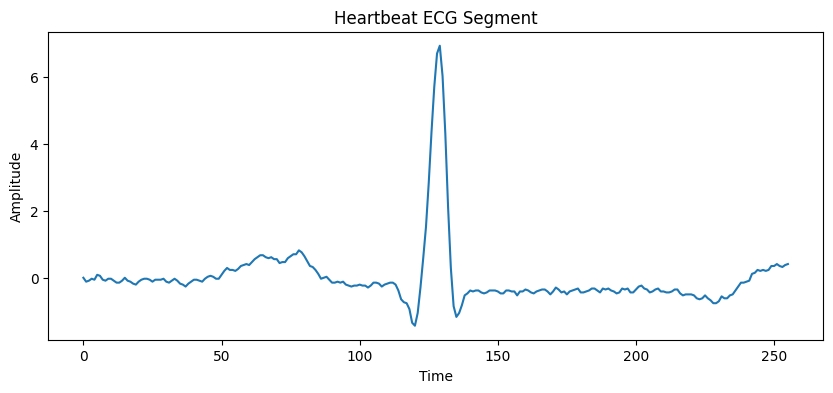

In [20]:
sample_signal = X_test[0]

plt.figure(figsize=(10,4))
plt.plot(sample_signal)

plt.title("Heartbeat ECG Segment")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

In [16]:
print(device)

cpu


In [24]:
cm = confusion_matrix(
    true_labels,
    predictions
)

print(cm)

[[839   0]
 [  8 420]]


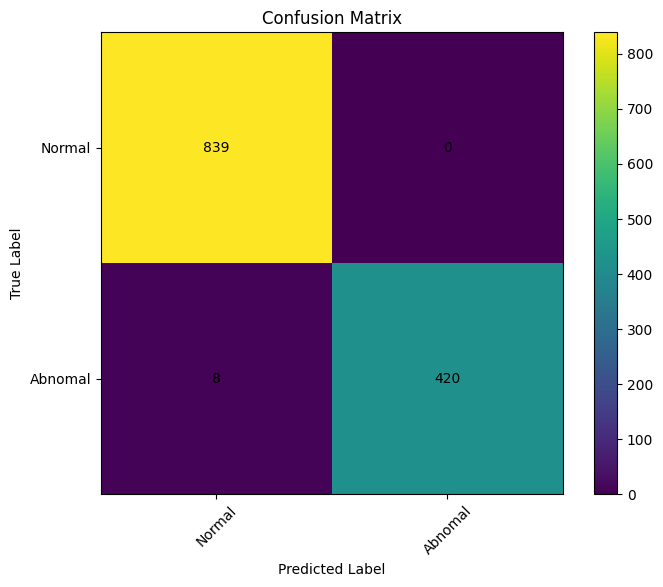

In [27]:
class_names = [
    'Normal',
    'Abnomal'
]

plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

tick_marks = np.arange(len(class_names))

plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add numbers inside cells
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center'
        )

plt.show()

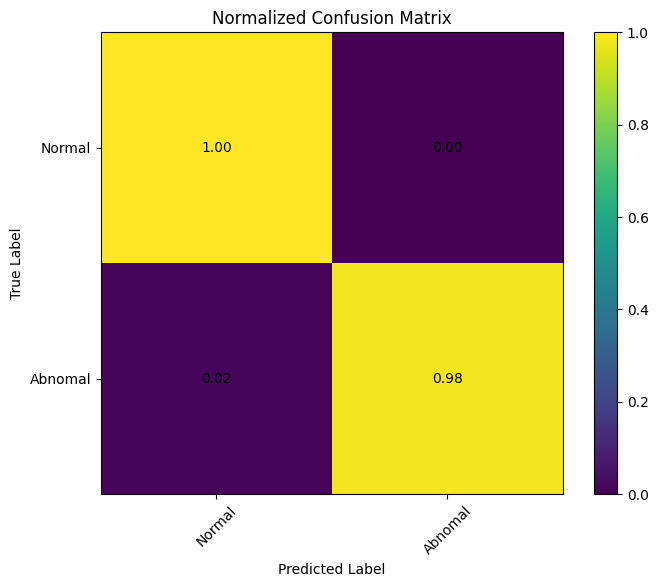

In [28]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))

plt.imshow(cm_normalized)

plt.title("Normalized Confusion Matrix")

plt.colorbar()

plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(len(class_names)):
    for j in range(len(class_names)):

        plt.text(
            j,
            i,
            f"{cm_normalized[i, j]:.2f}",
            ha='center',
            va='center'
        )

plt.show()